<a href="https://colab.research.google.com/github/nasywafunnisa/pengolahan-citra-digital/blob/main/tugas_transformasi_geometrik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload gambar (jpg/png)...


Saving tegak.jpg to tegak.jpg
Ukuran gambar: (600, 600, 3)


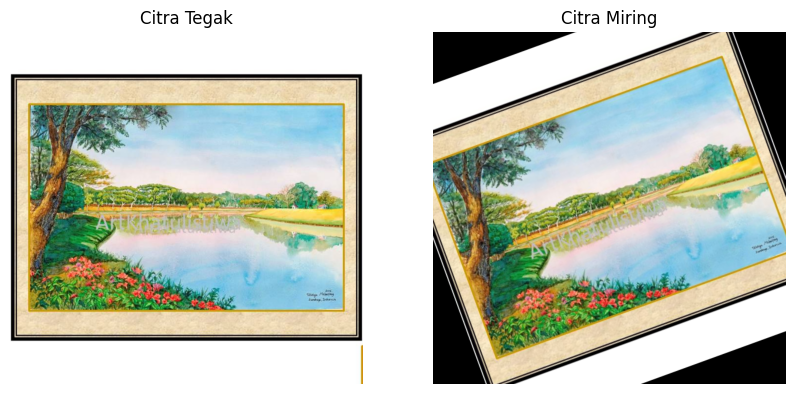


=== 1. Translasi ===


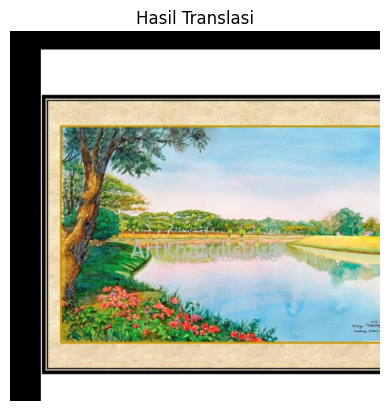


=== 2. Rotasi ===


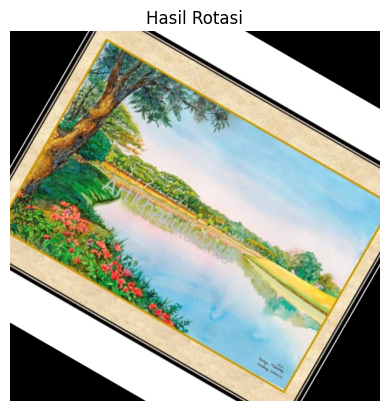


=== 3. Scaling ===


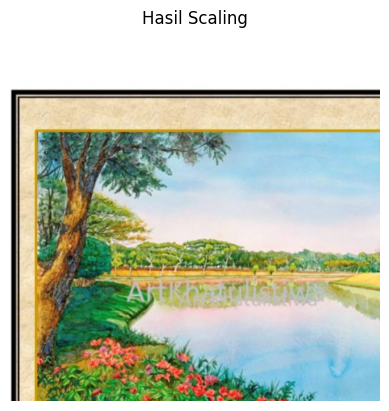


=== 4. Transformasi Affine ===


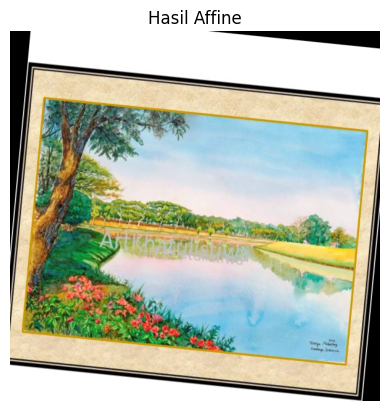


=== 5. Transformasi Perspektif ===


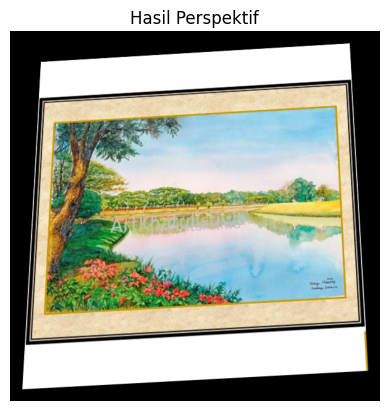


=== 6. Evaluasi Interpolasi (Rotasi) ===
Nearest
  MSE  : 6934.33
  PSNR : 9.72 dB
  Time : 3.453 ms

Bilinear
  MSE  : 6904.88
  PSNR : 9.74 dB
  Time : 4.052 ms

Bicubic
  MSE  : 6867.49
  PSNR : 9.76 dB
  Time : 13.646 ms



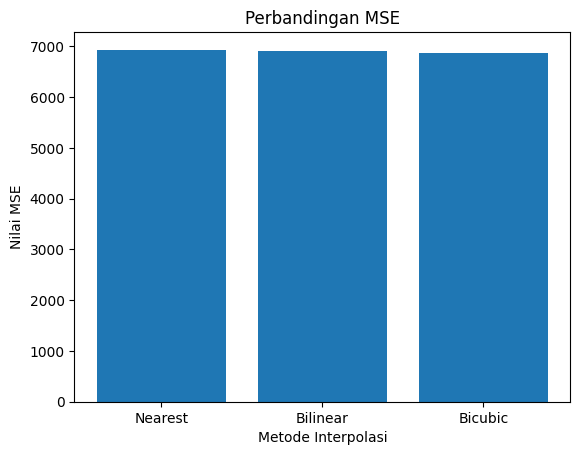

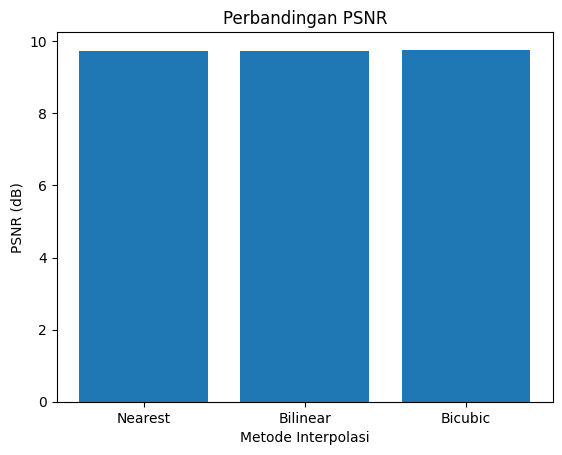

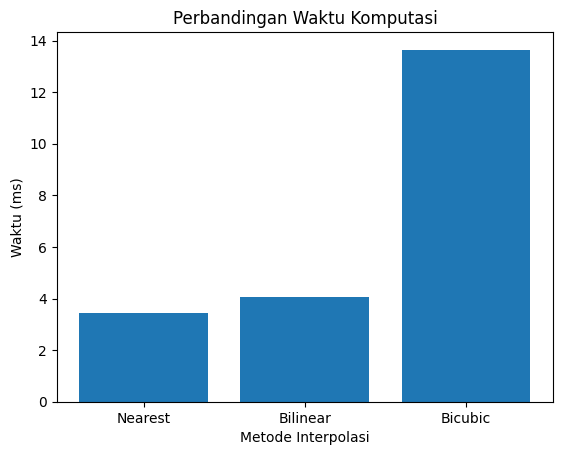

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import math
from google.colab import files

# 1️. UPLOAD GAMBAR
print("Upload gambar (jpg/png)...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

H, W = img.shape[:2]

# Resize agar stabil
img = cv2.resize(img, (600, int(600*H/W)))
H, W = img.shape[:2]

print("Ukuran gambar:", img.shape)

# 2️. TAMPILKAN TEGAK & MIRING
M_rot_miring = cv2.getRotationMatrix2D((W//2, H//2), 20, 1.0)
img_miring = cv2.warpAffine(img, M_rot_miring, (W, H))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Tegak")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_miring)
plt.title("Citra Miring")
plt.axis('off')
plt.show()

# 3️. TRANSLASI (HOMOGEN)
print("\n=== 1. Translasi ===")

T = np.array([[1,0,50],
              [0,1,30],
              [0,0,1]], dtype=np.float32)

img_trans = cv2.warpPerspective(img, T, (W,H))

plt.imshow(img_trans)
plt.title("Hasil Translasi")
plt.axis('off')
plt.show()

# 4️. ROTASI (HOMOGEN PUSAT)
print("\n=== 2. Rotasi ===")

angle = 30
theta = np.radians(angle)

T1 = np.array([[1,0,-W/2],
               [0,1,-H/2],
               [0,0,1]], dtype=np.float32)

R = np.array([[np.cos(theta), -np.sin(theta), 0],
              [np.sin(theta),  np.cos(theta), 0],
              [0,0,1]], dtype=np.float32)

T2 = np.array([[1,0,W/2],
               [0,1,H/2],
               [0,0,1]], dtype=np.float32)

M_rot = T2 @ R @ T1

img_rot = cv2.warpPerspective(img, M_rot, (W,H))

plt.imshow(img_rot)
plt.title("Hasil Rotasi")
plt.axis('off')
plt.show()

# 5️. SCALING (HOMOGEN)
print("\n=== 3. Scaling ===")

S = np.array([[1.3,0,0],
              [0,1.3,0],
              [0,0,1]], dtype=np.float32)

img_scale = cv2.warpPerspective(img, S, (W,H))

plt.imshow(img_scale)
plt.title("Hasil Scaling")
plt.axis('off')
plt.show()

# 6️. AFFINE (3 TITIK)
print("\n=== 4. Transformasi Affine ===")

pts_src = np.float32([[50,50],[W-50,50],[50,H-50]])
pts_dst = np.float32([[80,30],[W-30,80],[30,H-30]])

M_affine = cv2.getAffineTransform(pts_src, pts_dst)
img_affine = cv2.warpAffine(img, M_affine, (W,H))

plt.imshow(img_affine)
plt.title("Hasil Affine")
plt.axis('off')
plt.show()

# 7️. PERSPEKTIF (4 TITIK)
print("\n=== 5. Transformasi Perspektif ===")

pts4_src = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1]])
pts4_dst = np.float32([[50,50],[W-50,20],[W-20,H-50],[20,H-20]])

M_persp = cv2.getPerspectiveTransform(pts4_src, pts4_dst)
img_persp = cv2.warpPerspective(img, M_persp, (W,H))

plt.imshow(img_persp)
plt.title("Hasil Perspektif")
plt.axis('off')
plt.show()

# 8️. INTERPOLASI + EVALUASI
print("\n=== 6. Evaluasi Interpolasi (Rotasi) ===")

def mse(a, b):
    return np.mean((a.astype(np.float64) - b.astype(np.float64))**2)

def psnr(a, b):
    m = mse(a, b)
    return float('inf') if m == 0 else 10*math.log10(255**2/m)

ref_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

interps = {
    "Nearest": cv2.INTER_NEAREST,
    "Bilinear": cv2.INTER_LINEAR,
    "Bicubic": cv2.INTER_CUBIC
}

results = {}

for name, flag in interps.items():
    start = time.perf_counter()

    warped = cv2.warpAffine(img, M_rot_miring, (W,H), flags=flag)

    end = time.perf_counter()

    rec = cv2.warpAffine(warped,
                         cv2.getRotationMatrix2D((W//2,H//2), -20,1),
                         (W,H),
                         flags=flag)

    rec_gray = cv2.cvtColor(rec, cv2.COLOR_RGB2GRAY)

    results[name] = {
        "MSE": mse(ref_gray, rec_gray),
        "PSNR": psnr(ref_gray, rec_gray),
        "Time": (end-start)*1000
    }

    print(f"{name}")
    print(f"  MSE  : {results[name]['MSE']:.2f}")
    print(f"  PSNR : {results[name]['PSNR']:.2f} dB")
    print(f"  Time : {results[name]['Time']:.3f} ms\n")

# 9️. GRAFIK PERBANDINGAN

methods = list(results.keys())
mse_vals = [results[m]["MSE"] for m in methods]
psnr_vals = [results[m]["PSNR"] for m in methods]
time_vals = [results[m]["Time"] for m in methods]

# MSE
plt.figure()
plt.bar(methods, mse_vals)
plt.title("Perbandingan MSE")
plt.ylabel("Nilai MSE")
plt.xlabel("Metode Interpolasi")
plt.show()

# PSNR
plt.figure()
plt.bar(methods, psnr_vals)
plt.title("Perbandingan PSNR")
plt.ylabel("PSNR (dB)")
plt.xlabel("Metode Interpolasi")
plt.show()

# Waktu
plt.figure()
plt.bar(methods, time_vals)
plt.title("Perbandingan Waktu Komputasi")
plt.ylabel("Waktu (ms)")
plt.xlabel("Metode Interpolasi")
plt.show()